### Model Comparisons

In [1]:
import os

cwd = os.getcwd()
print(cwd)

change_cwd = os.chdir("../../models")
pwd = %pwd
print(pwd)

/home/rc/Academia/capstone/notebooks/test
/home/rc/Academia/capstone/models


In [ ]:
import kagglehub
import pandas as pd
import tqdm 

path = kagglehub.dataset_download("rajanand/key-indicators-of-annual-health-survey")
print(f"Kaggle Health Analytics data repository:")
print("Dataset at:", path)
print("Files:", os.listdir(path))

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
districtwise_file = next(f for f in csv_files if 'districtwise' in f.lower())
dataset = os.path.join(path, districtwise_file)

df = pd.read_csv(dataset)
print(f"\nPrimary dataset: {districtwise_file}")
print(f"✅ Dataframe shape: {df.shape} (expected ~284 rows x 644 features)")

%mkdir ../data

%ls ~/.cache/kagglehub/datasets/rajanand/key-indicators-of-annual-health-survey/versions/1
%cp -r ~/.cache/kagglehub/datasets/rajanand/key-indicators-of-annual-health-survey/versions/1/* ../data/

In [ ]:
# XGBoost Baseline
!python xgboost_baseline.py --data ../data/Key_indicator_districtwise.csv \
--target YY_Infant_Mortality_Rate_Imr_Total_Person --id-cols State_Name State_District_Name \
--outdir ../notebooks/test/xgboost-baseline

In [ ]:
# KNN
!python knn_model.py \
--data ../data/Key_indicator_districtwise.csv \
--target Infant_Mortality_Rate_Imr_Total_Person \
--id-cols State_Name State_District_Name \
--correlation 72 --test-size 0.24 --random-state 42 --outdir ../notebooks/test/knn-model

In [ ]:
# JAX/Keras DNN
!python keras_dnn.py \
--data ../data/Key_indicator_districtwise.csv \
--target Infant_Mortality_Rate_Imr_Total_Person \
--id-cols State_Name State_District_Name \
--lr 0.0009 --dropout 0.15 --l2-reg 0.01 --epochs 500 \
--correlation 72 --vif-threshold 11 --test-size 0.25 --val-size 0.10 \
--random-state 42 --outdir ../notebooks/test/keras-dnn-final-submission

In [67]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

xgboost_metrics = pd.read_csv('../notebooks/test/xgboost-baseline/metrics.csv')
knn_metrics = pd.read_csv('../notebooks/test/knn-model/metrics.csv')
keras_metrics = pd.read_csv('../notebooks/test/keras-dnn-final-submission/metrics.csv')

comparison = pd.DataFrame({
    'Model': ['XGBoost Baseline Model', 'KNN Model', 'JAX/Keras DNN'],
    'Test R²': [xgboost_metrics['R2'][1], knn_metrics['R2'][1], keras_metrics['R2'][1]],
    'Test Adj. R²': [xgboost_metrics['Adj_R2'][1], knn_metrics['Adj_R2'][0], keras_metrics['Adj_R2'][1]],
    'Test RMSE': [xgboost_metrics['RMSE'][1], knn_metrics['RMSE'][1], keras_metrics['RMSE'][1]],
    'Test MAE': [xgboost_metrics['MAE'][1], knn_metrics['MAE'][1], keras_metrics['MAE'][1]],
})
comparison

,Model,Test R²,Test Adj. R²,Test RMSE,Test MAE
0,XGBoost Baseline Model,0.9845,1.0015,1.9861,1.0045
1,KNN Model,0.9936,0.9954,1.2581,0.7158
2,JAX/Keras DNN,0.9694,0.9643,2.7082,2.1835


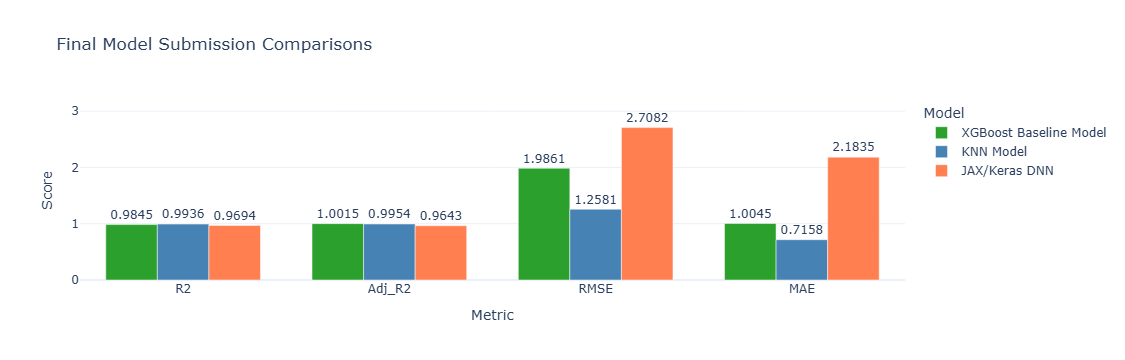

In [66]:
import plotly.express as px

xgboost_metrics = pd.read_csv('../notebooks/test/xgboost-baseline/metrics.csv')
knn_metrics = pd.read_csv('../notebooks/test/knn-model/metrics.csv')
keras_metrics = pd.read_csv('../notebooks/test/keras-dnn-final-submission/metrics.csv')

comparison = pd.DataFrame({
    'Model': ['XGBoost Baseline Model', 'KNN Model', 'JAX/Keras DNN'],
    'R2': [xgboost_metrics['R2'].iloc[1], knn_metrics['R2'].iloc[1], keras_metrics['R2'].iloc[1]],
    'Adj_R2': [xgboost_metrics['Adj_R2'].iloc[1], knn_metrics['Adj_R2'].iloc[0], keras_metrics['Adj_R2'].iloc[1]],
    'RMSE': [xgboost_metrics['RMSE'].iloc[1], knn_metrics['RMSE'].iloc[1], keras_metrics['RMSE'].iloc[1]],
    'MAE': [xgboost_metrics['MAE'].iloc[1], knn_metrics['MAE'].iloc[1], keras_metrics['MAE'].iloc[1]],
})

long_df = comparison.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

fig = px.bar(
    long_df,
    x='Metric',
    y='Score',
    color='Model',
    barmode='group',
    text='Score',
    title='Final Model Submission Comparisons',
    color_discrete_map={
        'XGBoost Baseline Model': '#2CA02C',    
        'KNN Model': '#4682B4',                 
        'JAX/Keras DNN': '#FF7F50'              
    }
)

fig.update_traces(texttemplate='%{text:.4f}', textposition='outside')
fig.update_layout(
    xaxis_title='Metric',
    yaxis_title='Score',
    legend_title='Model',
    bargap=0.25,
    template='plotly_white'
)
fig.show()